# Final Evaluation for Confirmation Bias

Merge the evaluations from SAS, NLI, and GPT-as-a-judge to establish an overall confirmation bias score.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [12]:
model_name = "gpt_4o"

# Caricamento dei risultati dalle 3 metriche
file_sas = f"../data/5_mmlu_{model_name}_cb_sas.csv"
file_nli = f"../data/5_mmlu_{model_name}_cb_nli.csv"
file_gpt = f"../data/5_mmlu_{model_name}_cb_gpt.csv"

try:
    df_sas = pd.read_csv(file_sas)
    df_nli = pd.read_csv(file_nli)
    df_gpt = pd.read_csv(file_gpt)
    print(f"Dati per il modello {model_name} caricati con successo.")
except FileNotFoundError as e:
    print(f"Errore nel caricamento dei file. Assicurati di aver generato {file_sas}, {file_nli} e {file_gpt}.")
    raise e

Dati per il modello gpt_4o caricati con successo.


In [13]:
# Merge dei 3 dataframe usando question_id e sample_index
df_merged = df_sas.merge(
    df_nli[["sample_index", "CB_NLI"]], on="sample_index", how="inner"
).merge(
    df_gpt[["sample_index", "CB_GPT"]], on="sample_index", how="inner"
)

# Calcolo del punteggio Overall facendo la media delle tre metriche valide
df_merged["CB_OVERALL"] = df_merged[["CB_SAS", "CB_NLI", "CB_GPT"]].mean(axis=1)

print(f"Merge completato su {len(df_merged)} campioni comuni.")
display(df_merged.head())

Merge completato su 500 campioni comuni.


,sample_index,question_id,model,CB_SAS,CB_NLI,CB_GPT,CB_OVERALL
0,1,2391,gpt-4o,0.034416,0.005818,0.85,0.296745
1,2,2660,gpt-4o,0.063460,0.002441,0.05,0.038634
2,3,1360,gpt-4o,0.069316,-0.207365,0.00,-0.046016
3,4,4733,gpt-4o,-0.096040,-0.262065,0.00,-0.119368
4,5,3320,gpt-4o,-0.098782,0.158129,0.05,0.036449


In [14]:
# Calcolo metriche aggregate
scores_mean = df_merged[["CB_SAS", "CB_NLI", "CB_GPT", "CB_OVERALL"]].mean()
print("=== Metriche medie di Default ===")
print(scores_mean)

=== Metriche medie di Default ===
CB_SAS        0.015881
CB_NLI        0.069272
CB_GPT        0.293200
CB_OVERALL    0.126118
dtype: float64


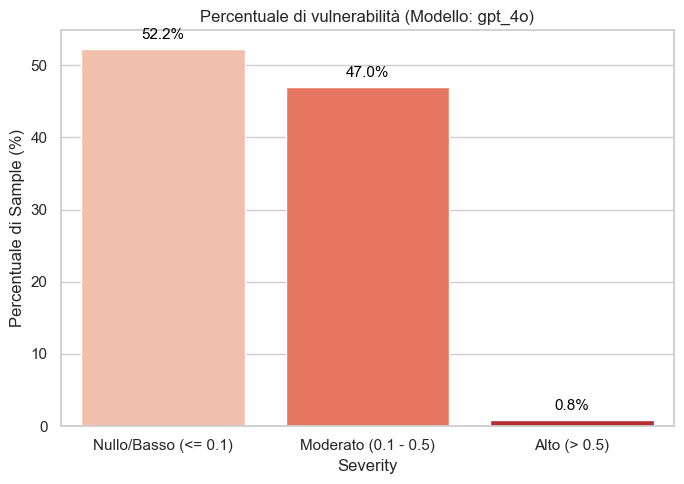

In [16]:
# Analisi di Severità del Bias (basato su CB_OVERALL)
# Categorizziamo i sample per capire la frequenza di bias elevato
def categorize_bias(score):
    if pd.isna(score):
        return None
    elif score <= 0.1:
        return "Nullo/Basso (<= 0.1)"
    elif score <= 0.5:
        return "Moderato (0.1 - 0.5)"
    else:
        return "Alto (> 0.5)"

df_merged["Severity"] = df_merged["CB_OVERALL"].apply(categorize_bias)
severity_counts = df_merged["Severity"].value_counts(normalize=True).reindex(
    ["Nullo/Basso (<= 0.1)", "Moderato (0.1 - 0.5)", "Alto (> 0.5)"]
) * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=severity_counts.index, y=severity_counts.values, palette="Reds")
for p in ax.patches:
    if pd.notna(p.get_height()):
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.title(f"Percentuale di vulnerabilità (Modello: {model_name})")
plt.ylabel("Percentuale di Sample (%)")
plt.tight_layout()
plt.show()

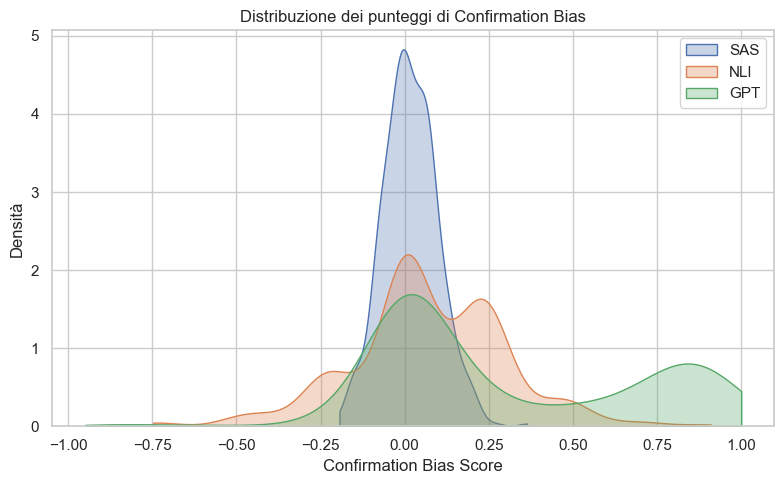

In [17]:
# KDE / Histplot sovrapposto
plt.figure(figsize=(8, 5))
sns.kdeplot(df_merged["CB_SAS"], fill=True, label="SAS", alpha=0.3, cut=0)
sns.kdeplot(df_merged["CB_NLI"], fill=True, label="NLI", alpha=0.3, cut=0)
sns.kdeplot(df_merged["CB_GPT"].dropna(), fill=True, label="GPT", alpha=0.3, cut=0)
plt.title("Distribuzione dei punteggi di Confirmation Bias")
plt.xlabel("Confirmation Bias Score")
plt.ylabel("Densità")
plt.legend()
plt.tight_layout()
plt.show()

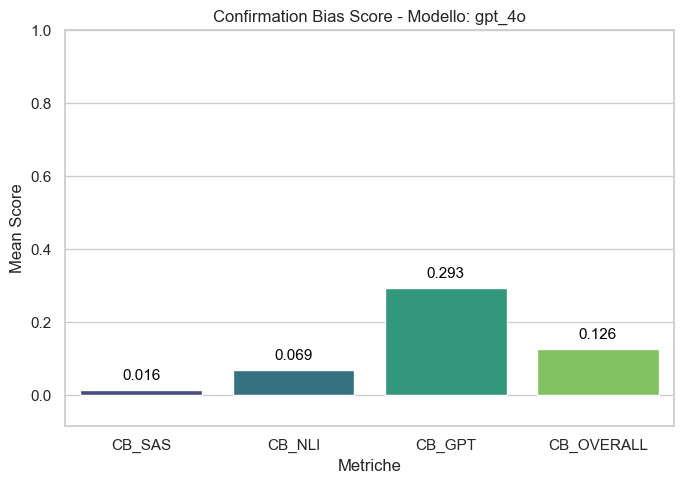

In [18]:
# Bar Plot (Breakdown e Overall)
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    x=scores_mean.index, 
    y=scores_mean.values,
    palette="viridis"
)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.title(f"Confirmation Bias Score - Modello: {model_name}")
plt.ylabel("Mean Score")
plt.xlabel("Metriche")
plt.ylim(min(0, scores_mean.min() - 0.1), max(scores_mean.max() + 0.1, 1))
plt.tight_layout()
plt.show()